In [1]:
# Install dependencies (if needed)
!pip install torch torchvision matplotlib

import torch
import torch.nn as nn
import torch.optim as optim
import torchvision.transforms as transforms
from torchvision.utils import make_grid
import matplotlib.pyplot as plt
import numpy as np

In [4]:
class Generator(nn.Module):
    def __init__(self):
        super(Generator, self).__init__()

        self.model = nn.Sequential(
            nn.Conv2d(3, 64, 4, 2, 1),   # Downsample
            nn.ReLU(),

            nn.Conv2d(64, 128, 4, 2, 1),
            nn.BatchNorm2d(128),
            nn.ReLU(),

            nn.ConvTranspose2d(128, 64, 4, 2, 1),  # Upsample
            nn.BatchNorm2d(64),
            nn.ReLU(),

            nn.ConvTranspose2d(64, 3, 4, 2, 1),
            nn.Tanh()
        )

    def forward(self, x):
        return self.model(x)

In [3]:
class Discriminator(nn.Module):
    def __init__(self):
        super(Discriminator, self).__init__()

        self.model = nn.Sequential(
            nn.Conv2d(6, 64, 4, 2, 1),
            nn.LeakyReLU(0.2),

            nn.Conv2d(64, 128, 4, 2, 1),
            nn.BatchNorm2d(128),
            nn.LeakyReLU(0.2),

            nn.Conv2d(128, 1, 4, 1, 1),
            nn.Sigmoid()
        )

    def forward(self, x, y):
        # Concatenate input & target image
        combined = torch.cat([x, y], dim=1)
        return self.model(combined)

In [5]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

G = Generator().to(device)
D = Discriminator().to(device)

criterion = nn.BCELoss()
L1_loss = nn.L1Loss()

optimizer_G = optim.Adam(G.parameters(), lr=0.0002)
optimizer_D = optim.Adam(D.parameters(), lr=0.0002)

In [6]:
# Create random "input-output" image pairs
def get_dummy_data(batch_size=4):
    x = torch.randn(batch_size, 3, 64, 64).to(device)
    y = torch.randn(batch_size, 3, 64, 64).to(device)
    return x, y

In [7]:
epochs = 5

for epoch in range(epochs):
    x, real_y = get_dummy_data()

    # Real & Fake labels
    real_label = torch.ones((x.size(0), 1, 15, 15)).to(device)
    fake_label = torch.zeros((x.size(0), 1, 15, 15)).to(device)

    # ---------------------
    # Train Generator
    # ---------------------
    optimizer_G.zero_grad()

    fake_y = G(x)
    pred_fake = D(x, fake_y)

    loss_G_adv = criterion(pred_fake, real_label)
    loss_G_L1 = L1_loss(fake_y, real_y)

    loss_G = loss_G_adv + 100 * loss_G_L1
    loss_G.backward()
    optimizer_G.step()

    # ---------------------
    # Train Discriminator
    # ---------------------
    optimizer_D.zero_grad()

    pred_real = D(x, real_y)
    loss_real = criterion(pred_real, real_label)

    pred_fake = D(x, fake_y.detach())
    loss_fake = criterion(pred_fake, fake_label)

    loss_D = (loss_real + loss_fake) / 2
    loss_D.backward()
    optimizer_D.step()

    print(f"Epoch [{epoch+1}/{epochs}] | Loss D: {loss_D.item():.4f} | Loss G: {loss_G.item():.4f}")

Epoch [1/5] | Loss D: 0.7136 | Loss G: 95.4115
Epoch [2/5] | Loss D: 0.7058 | Loss G: 94.6393
Epoch [3/5] | Loss D: 0.7026 | Loss G: 94.2469
Epoch [4/5] | Loss D: 0.6964 | Loss G: 94.3688
Epoch [5/5] | Loss D: 0.6966 | Loss G: 93.7833


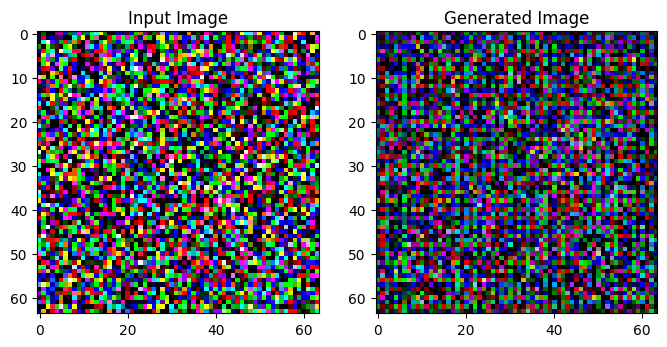

In [8]:
def show_images(input_img, generated_img):
    input_img = input_img[0].cpu().detach().numpy().transpose(1,2,0)
    generated_img = generated_img[0].cpu().detach().numpy().transpose(1,2,0)

    plt.figure(figsize=(8,4))

    plt.subplot(1,2,1)
    plt.title("Input Image")
    plt.imshow(input_img)

    plt.subplot(1,2,2)
    plt.title("Generated Image")
    plt.imshow(generated_img)

    plt.show()

# Generate sample
x, _ = get_dummy_data(1)
fake = G(x)

show_images(x, fake)